In [95]:
# import libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [96]:
# import database

In [97]:
conn = sqlite3.connect("customer_churn (2).db")
sql_querry = """ 
      SELECT name 
      FROM sqlite_master
      WHERE type='table'

"""
tables = pd.read_sql(sql_querry, conn)
# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe: df_{table_name}")
conn.close()


created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


In [98]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [99]:
#2 DATA CLEANING

In [100]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [101]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [102]:
# RENAME A COLUMN - (name)
# DROP COLUMNS - INTERESTS AND PINCODE
# CHANGE DATA TYPE - dob
# DATA STANDARDIZATIONM - gender
# FIX MISSING VALUES

In [103]:
# RENAME A COLUMN - (name)
df_db_customer.rename(columns = {'name' : 'cumtomer_name'}, inplace= True)  

In [104]:
# DROP COLUMNS - INTERESTS AND PINCODE
#df_db_customer.drop(df_db_customer.columns[-2: ], axis=1)
df_db_customer.drop(columns=['interests', 'pincode'], inplace= True)

In [105]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   cumtomer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [106]:
# CHANGE DATA TYPE - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [107]:
# DATA STANDARDIZATIONM - gender
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [108]:
# FIX MISSING VALUES
df_db_customer[df_db_customer['country'].isna()]

,customerid,cumtomer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [109]:
# country and state : unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [110]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [111]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [112]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [113]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [114]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [115]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [116]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [117]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [118]:
#Feature Engineering and Data Analysis

In [119]:
#create a new column using existing column - churn flag
df_db_subscription['chrun_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [120]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,chrun_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [121]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left')
    .merge(df_db_support, on = 'customerid', how= 'left'))

In [122]:
df.shape

(23, 20)

In [123]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,chrun_flag,cumtomer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [124]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [125]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [126]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [127]:
df_db_support['customerid'].size

7

In [128]:
#merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left')
    .merge(df_db_support, on = 'customerid', how= 'left'))

In [129]:
df.shape

(21, 21)

In [130]:
df.to_csv('exported_churn_data.csv', index=False)

In [131]:
#churn analysis

In [132]:
#1 churn rate

In [133]:

df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'chrun_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [134]:
chrun_rate = df['chrun_flag'].mean()*100
print("chrun rate = ", round(chrun_rate,2), "%")

chrun rate =  28.57 %


In [135]:
#2 Retention rate
retention_rate = 100- chrun_rate
print("Retention Rate = ", round(retention_rate, 2), "%")

Retention Rate =  71.43 %


In [136]:
df.head(2)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,chrun_flag,cumtomer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [137]:
#3 chrun by plan type
churn_by_plan = df.groupby('plan_type')['chrun_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print( churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [138]:
df = df.rename(columns={'chrun_flag': 'churn_flag'})

In [139]:
churn_rate_pct=('chrun_flag', lambda x: round(x.mean() * 100, 2)),

In [140]:
# 4a. Churn by state + sum(revenue) & count of users
churn_by_state = df.groupby('state').agg(
    churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [141]:
churn_by_subscription = df.groupby('subscription_type').agg(
    churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [142]:
#5 average revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [143]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count']


In [144]:
#6 Avg customer tenure 
# count of days users has used our services : cancellation date else current date
today = pd.Timestamp.today()

df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')

df['customer_age_days'] = (df['cancellation_date'].fillna(today) - df['subscription_start_date']).dt.days

avg_tenure = df['customer_age_days'].mean()
print('Average customer tenure (days) = ', round(avg_tenure, 0))

Average customer tenure (days) =  1535.0


In [145]:
#customers age
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['customer_age_years'] = ((today - df['dob']).dt.days / 365.25).round(1)
print(df[['customerid', 'customer_age_years']].head())

   customerid  customer_age_years
0  0002-ORFBO                44.4
1  0003-MKNFE                30.8
2  0004-TLHLJ                48.6
3  0011-IGKFF                25.0
4  0013-EXCHZ                36.3


In [146]:
#7 Revenue at risk - revenue lost from cuhurned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at risk (Rs 'K') =", revenue_at_risk)

Revenue at risk (Rs 'K') = 73.94


In [147]:
#8 Escalation Rate
excalation_rate = (df['escalations'] =='Y').mean()*100
print("excalation rate", round(excalation_rate, 2), "%")

excalation rate 19.05 %


In [148]:
#9 average complaint per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average complaints per user = ", round(avg_complaints, 2))

Average complaints per user =  0.43


In [149]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age_days', 'customer_age_years'],
      dtype='str')

In [150]:
#10 correlation escalation vs churn

In [151]:
# correlation escalation vs churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)  # encoding string to int type

correlation_df = df[['escalations', 'churn_flag']].dropna()
corr = correlation_df['escalations'].corr(correlation_df['churn_flag'])
print("Correlation between escalation vs churn flag is =", round(corr, 2))

Correlation between escalation vs churn flag is = 0.77


In [152]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,customer_age_days,customer_age_years
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2004,44.4
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501,30.8


In [153]:
df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [154]:

# 11. create a column using existing col - Churn risk  
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')





In [155]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,customer_age_days,customer_age_years,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2004,44.4,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501,30.8,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1389,48.6,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2679,25.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419,36.3,high


In [156]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\ritup\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [157]:
#11 Machine Learning - Predict Churn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Select features (drop leakage columns, IDs, names, raw dates)
drop_cols = ['customerid', 'cumtomer_name', 'cancellation_date', 'cancellation_reason',
             'churn_score', 'churn_flag', 'subscription_start_date', 'renewal_date',
             'dob', 'complaint_date']

X = df.drop(columns=drop_cols)
y = df['churn_flag']

# 2. Encode categorical columns
cat_cols = X.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# 3. Handle missing values
X = X.fillna(X.median(numeric_only=True))

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Train model
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 6. Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(confusion_matrix(y_test, y_pred))

# 7. Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

C:\Users\ritup\AppData\Local\Temp\ipykernel_21328\3183411525.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

ROC AUC: 1.0
[[4 0]
 [0 1]]
churn_risk            0.266839
customer_age_days     0.185812
subscription_type     0.103388
escalations           0.091039
csat_score            0.068036
cltv                  0.056962
monthly_charges       0.052936
state                 0.048605
complaint_count       0.047916
customer_age_years    0.033301
contract_type         0.025176
plan_type             0.012788
country               0.004120
gender                0.003083
dtype: float64


In [158]:
print("Original df size:", len(df))
print("X shape after cleaning:", X.shape)
print("y value counts:\n", y.value_counts())

Original df size: 21
X shape after cleaning: (21, 14)
y value counts:
 churn_flag
0    15
1     6
Name: count, dtype: int64


In [159]:
# Predict churn probability for ALL customers (not just the test set)
df['predicted_churn_prob'] = model.predict_proba(X)[:, 1]
df['predicted_churn_flag'] = model.predict(X)

print(df[['customerid', 'churn_flag', 'predicted_churn_flag', 'predicted_churn_prob']].head(10))

   customerid  churn_flag  predicted_churn_flag  predicted_churn_prob
0  0002-ORFBO           0                     0                 0.120
1  0003-MKNFE           1                     1                 0.905
2  0004-TLHLJ           0                     0                 0.185
3  0011-IGKFF           0                     0                 0.010
4  0013-EXCHZ           1                     1                 0.970
5  0013-MHZWF           0                     0                 0.190
6  0013-SMEOE           1                     1                 0.640
7  0014-BMAQU           0                     0                 0.000
8  0015-UOCOJ           0                     0                 0.130
9  0016-QLJIS           0                     0                 0.160


In [160]:
df['is_test_row'] = df.index.isin(X_test.index)

In [161]:
#4. Visualisation using Matplotlib:

In [162]:
df_visual = df.copy()

In [163]:
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age_days', 'customer_age_years', 'churn_risk',
       'predicted_churn_prob', 'predicted_churn_flag', 'is_test_row'],
      dtype='str')

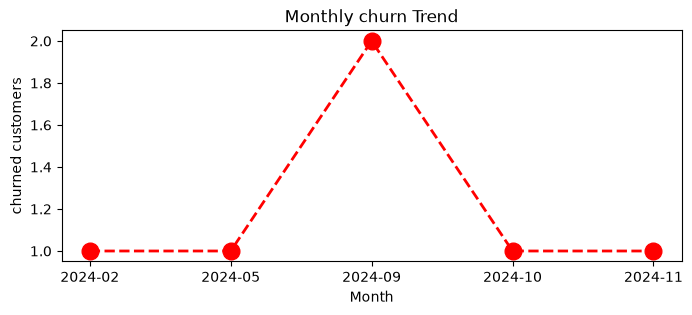

In [164]:
#4.1 Monthly Churn Trend:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag']== 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='red', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly churn Trend')
plt.xlabel('Month')
plt.ylabel('churned customers')
plt.show()

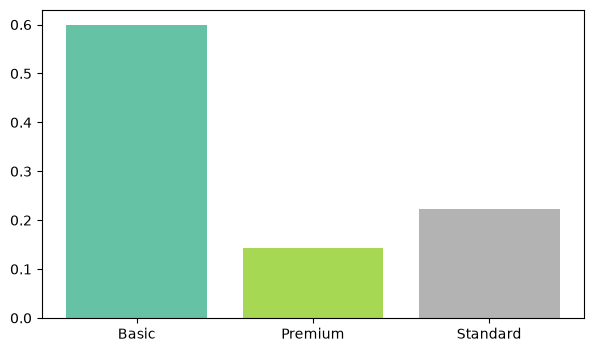

In [165]:
# 4.2 Churn by Plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()


colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.show()

In [166]:
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age_days', 'customer_age_years', 'churn_risk',
       'predicted_churn_prob', 'predicted_churn_flag', 'is_test_row',
       'cancellation_month'],
      dtype='str')

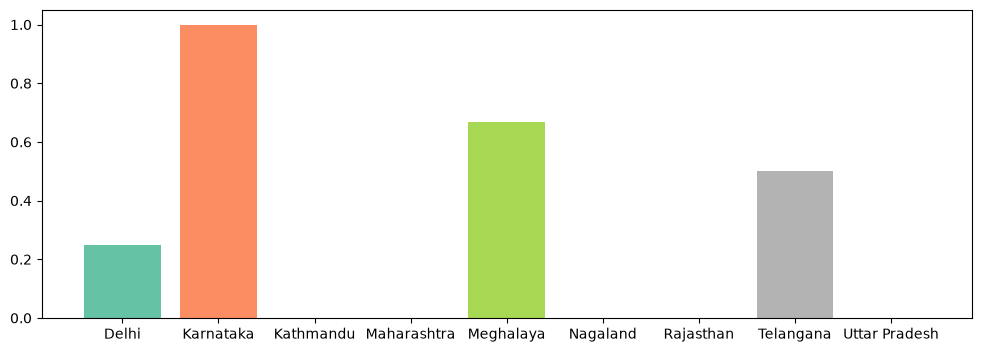

In [167]:
# 4.3 Churn by States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [168]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [169]:
#Visualisation using seaborn:

In [170]:
#encoding - convert str to numeric so that we can find corr between

In [171]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age_days', 'customer_age_years', 'churn_risk',
       'predicted_churn_prob', 'predicted_churn_flag', 'is_test_row',
       'cancellation_month'],
      dtype='str')

In [172]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [173]:
 df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

In [174]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

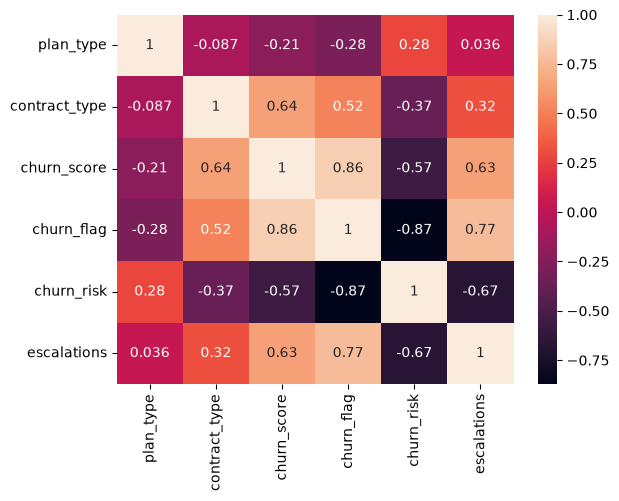

In [175]:
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)

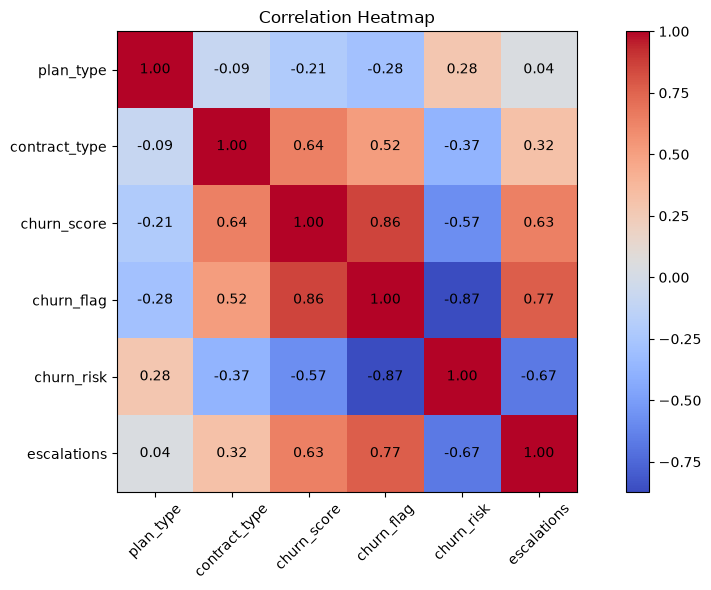

In [176]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis Labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

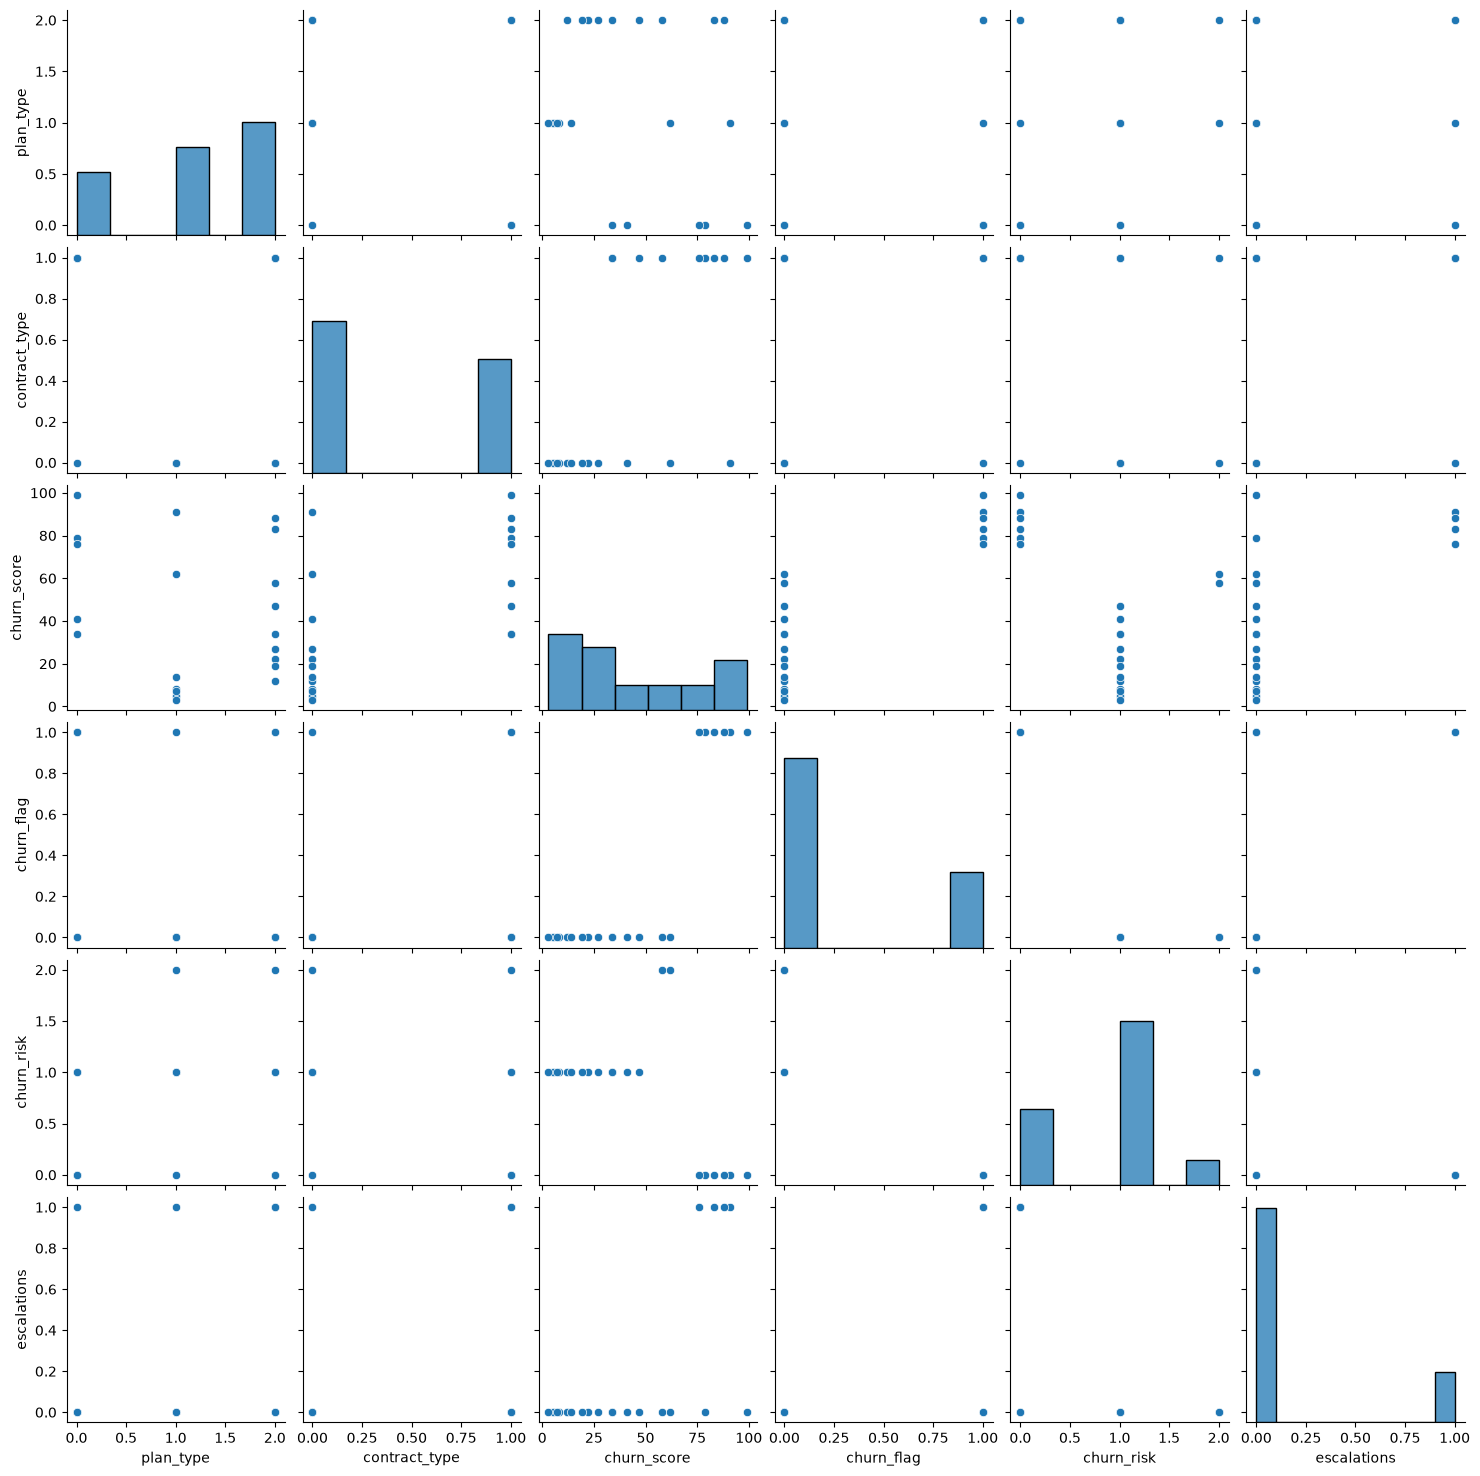

In [177]:
#pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [178]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cumtomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age_days', 'customer_age_years', 'churn_risk',
       'predicted_churn_prob', 'predicted_churn_flag', 'is_test_row',
       'cancellation_month'],
      dtype='str')

In [179]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [180]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [181]:
 df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


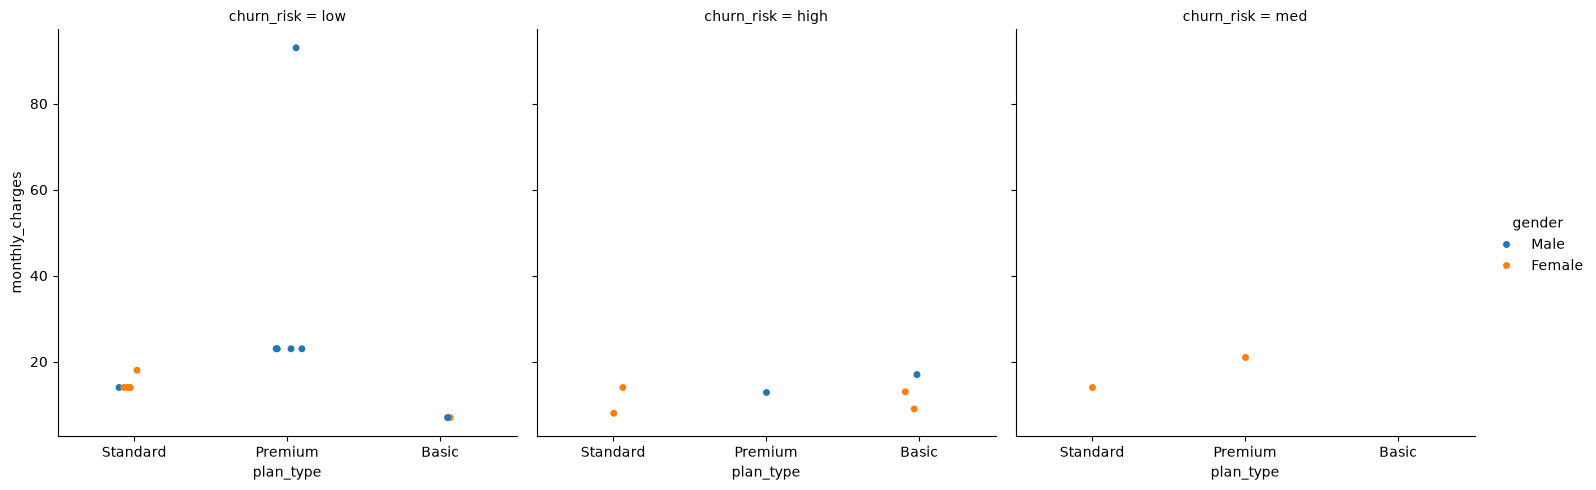

In [182]:
# catplot/facegrid plot - multi-dim comparison

sns.catplot( data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk',)

In [183]:
#Pivot table

In [184]:
pd.pivot_table(
     df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [185]:
pd.pivot_table(
     df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [186]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [187]:
# Working with SQL in PYTHON (pandas)

In [203]:
# recreate connection and cursor
conn = sqlite3.connect('test_database.sqlite')
cursor = conn.cursor()

In [204]:
conn.execute("DROP TABLE IF EXISTS users")
conn.execute("CREATE TABLE users(first_name TEXT, country TEXT, budget INTEGER)")

In [205]:
# recreate connection and cursor
conn = sqlite3.connect('test_database.sqlite')
cursor = conn.cursor()

In [206]:
cursor.execute(
    """
    INSERT INTO users VALUES
        ('Madhav', 'india', 5000),
        ('Rishabh', 'Germany', 2500),
        ('Vishakha', 'India', 3500)
    """
)

conn.commit()
print("Data Inserted successfully!")

Data Inserted successfully!


In [207]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,india,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [208]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,3500
2,india,5000


In [209]:
conn.close()